# Alignments for the Wavefront Sensor

francisho@lbl.gov, Nov 2025

(based on script by awojdyla@lb.gov, Sept 2024)



# SETUP


## Import 

(if there is an issue, do !pip instal package and restart the kernel)

In [2]:
import sys
import time

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pypylon import pylon

In [3]:
# location of a berkeley lab specific python to reac labview through tcp port
sys.path.append("C:\\Users\\lbnl-guest\\python")
import bcs_tcp

## Connecting to Camera and Motors

For motors, first make sure LabView is running. 

In [4]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())
# camera ip is 192.168.10.70
# a2A1920-51gcBAS (3000, 4096), ? um pixel size
# px_um = 3.45 ?
# distance to camera 150 mm ?
d_m = 0.15

In [5]:
# Control motor through bcs tcp interface
(host_ip_addr, host_port, host_timeout) = ('localhost',55000,5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Identify strings
bcs_id_linear = 'Galil x.20 A'  # linear stage
bcs_id_rotary = 'Galil x.20 B'  # rotary stage

# Raw data access -- please avoid, for debugging only
# pos = bcs.GetMotorPos(bcs_id_rotary)
# print(pos)

### Custom function to record rotary motor position

In [54]:
rotary_motor_rev = 0.0  # Initial state corresponding to 'open'

def move_rotary_motor(value):
    if value < 0:
        raise ValueError("Value must be non-negative")
    elif abs(value) > 1.0:
        raise ValueError("Value must be between 0 and 1.0")
    else: 
        bcs.MoveMotor(bcs_id_rotary, value)

    global rotary_motor_rev
    rotary_motor_rev += value  # Add the movement value to the current state
    if rotary_motor_rev >= 1-1e-6:
        rotary_motor_rev -= 1.0  # Subtract 1 to keep it within a cycle (0 to 1)
    elif rotary_motor_rev < 0-1e-6:
        rotary_motor_rev += 1.0  # Add 1 to keep it within a cycle (0 to 1)
    # Print the current state
    print(f"Current state: {rotary_motor_rev:.2f}")
    
    # Determine the output based on the new state
    if 0.45 < rotary_motor_rev < 0.55:
        return "close"
    elif rotary_motor_rev < 0.05 or rotary_motor_rev > 0.95:
        return "open"
    else:
        return

# Example usage
# print(move_rotary_motor(0.3))  # Moves to 0.3
# print(move_rotary_motor(0.3))  # Moves to 0.6
# print(move_rotary_motor(0.5))  # Moves to 1.1 (wraps around to 0.1)
# print(move_rotary_motor(0.9))  # Moves to 1.0, Outputs: 'close'
# print(move_rotary_motor(0.5))  # Moves to 0.6
# print(move_rotary_motor(-0.6)) # Moves to 0.0, Outputs: 'open'

## Test Controling Camera and Motors


### Camera control


In [5]:
# Test controling camera to grab an image

timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera

(3000, 4096)
78


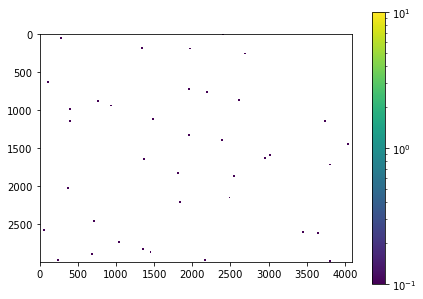

In [6]:
img_np = np.array(img.Array)
print(img_np.shape)
print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np, norm=LogNorm(vmin=1e-1, vmax=1e1))
plt.colorbar()
plt.show()

### Motor control


In [7]:
# Test linear motor control

str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 10.0 mm


In [8]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, 10)  # Move to an absolute position 

str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 10.0 mm


In [9]:
# Test rotary motor control

str_pos_rot_rev = bcs.GetMotorPos(bcs_id_rotary)
pos_rot_rev= float(str_pos_rot_rev.rstrip())

print('rotary stage position is %1.1f rev (1/360deg)' %pos_rot_rev)
print('rotary stage position is %1.1f deg ' %(pos_rot_rev*360))

rotary stage position is 0.0 rev (1/360deg)
rotary stage position is 0.0 deg 


In [10]:
# Move rotary stage
bcs.MoveMotor(bcs_id_rotary, 0.1)  # Move to an RELATIVE position

'Move Started\r\n'

Currently the rotary motor has NO reading, so one has to manually keep track on how/whether it's moved. 

Unlike for linear motor, the MoveMotor for rotary motor is __RELATIVE, i.e., if `bcs.MoveMotor(bcs_id_rotary, 0)`, nothing will be moved__.  


# ALIGNMENT 1124

Use rotary motor to align the beam. 

## Direct Beam on YAG

210523


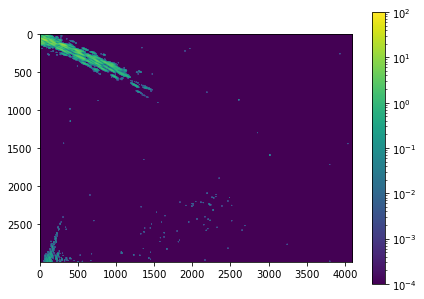

In [78]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

213425


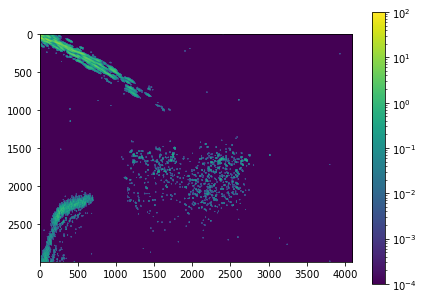

In [80]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

213425


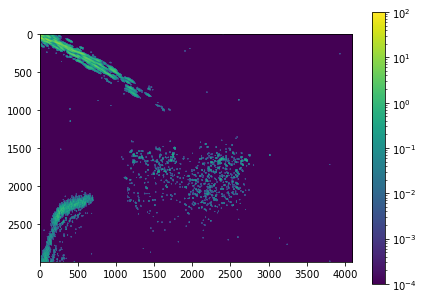

In [ ]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

## Move Beam Away

78


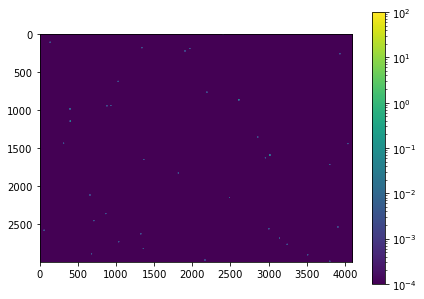

In [11]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

plt.figure(figsize=(7,5))
plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

In [180]:
is_open = True

def toggle():
    global is_open
    is_open = not is_open  # Toggle the state
    return 'open' if is_open else 'close'

# Call this function to toggle the state and display the result
print(toggle())  # Outputs: 'close' (if was 'open' initially)
print(toggle())  # Outputs: 'open' (if was 'close' in previous call)

close
open


In [181]:
bcs.MoveMotor(bcs_id_rotary, 0.5)
print(toggle())

close


In [208]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

# plt.figure(figsize=(7,5))
# plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
# plt.colorbar()
# plt.show()

86


In [232]:
bcs.MoveMotor(bcs_id_rotary, -0.05)

timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

72


# ALIGNMENT 1125


In [16]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, 0)  # Move to an absolute position 

'Move Started\r\n'

In [17]:
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 0.0 mm


## Direct Beam on YAG

727305


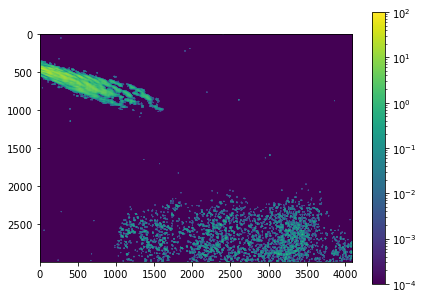

In [19]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

## Move Beam Away

83


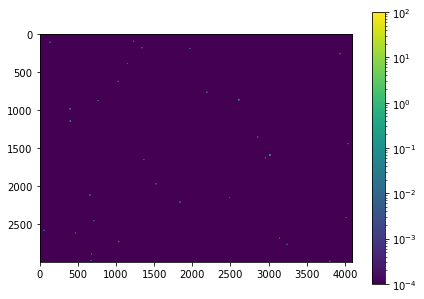

In [20]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

plt.figure(figsize=(7,5))
plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

In [21]:
is_open = True

def toggle():
    global is_open
    is_open = not is_open  # Toggle the state
    return 'open' if is_open else 'close'

# Call this function to toggle the state and display the result
print(toggle())  # Outputs: 'close' (if was 'open' initially)
print(toggle())  # Outputs: 'open' (if was 'close' in previous call)

close
open


In [22]:
bcs.MoveMotor(bcs_id_rotary, 0.5)
print(toggle())

close


In [23]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

# plt.figure(figsize=(7,5))
# plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
# plt.colorbar()
# plt.show()

78


In [67]:
bcs.MoveMotor(bcs_id_rotary, -0.05)

timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

90


In [76]:
bcs.MoveMotor(bcs_id_rotary, 0.5)
print(toggle())

open


In [75]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

# plt.figure(figsize=(7,5))
# plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
# plt.colorbar()
# plt.show()

77


## Define a Function to Control Rotary Motions

In [150]:
state = 0.0  # Initial state corresponding to 'open'

def move_rotary_motor(value):
    
    bcs.MoveMotor(bcs_id_rotary, value)

    global state
    state += value  # Add the movement value to the current state
    if state >= 1-1e-6:
        state -= 1.0  # Subtract 1 to keep it within a cycle (0 to 1)
    elif state < 0-1e-6:
        state += 1.0  # Add 1 to keep it within a cycle (0 to 1)

    # Print the current state
    print(f"Current state: {state:.2f}")
    
    # Determine the output based on the new state
    if 0.45 < state < 0.55:
        return "close"
    elif state < 0.05 or state > 0.95:
        return "open"
    else:
        return

# Example usage
# print(move_rotary_motor(0.3))  # Moves to 0.3
# print(move_rotary_motor(0.3))  # Moves to 0.6
# print(move_rotary_motor(0.5))  # Moves to 1.1 (wraps around to 0.1)
# print(move_rotary_motor(0.9))  # Moves to 1.0, Outputs: 'close'
# print(move_rotary_motor(0.5))  # Moves to 0.6
# print(move_rotary_motor(-0.6)) # Moves to 0.0, Outputs: 'open'

In [155]:
print(move_rotary_motor(0.5))

Current state: 0.50
close


In [121]:
# 20 points with a step of 0.05

sum_intensities = []

for i in range(20):
    value = 0.05  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(0.5)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

Current state: 0.05
Sum intensity: 72
Current state: 0.10
Sum intensity: 76
Current state: 0.15
Sum intensity: 75
Current state: 0.20
Sum intensity: 82
Current state: 0.25
Sum intensity: 84
Current state: 0.30
Sum intensity: 88
Current state: 0.35
Sum intensity: 145
Current state: 0.40
Sum intensity: 88
Current state: 0.45
Sum intensity: 79
Current state: 0.50
Sum intensity: 84
Current state: 0.55
Sum intensity: 84
Current state: 0.60
Sum intensity: 86
Current state: 0.65
Sum intensity: 88
Current state: 0.70
Sum intensity: 85
Current state: 0.75
Sum intensity: 87
Current state: 0.80
Sum intensity: 89
Current state: 0.85
Sum intensity: 87
Current state: 0.90
Sum intensity: 83
Current state: 0.95
Sum intensity: 90
Current state: 0.00
Sum intensity: 87


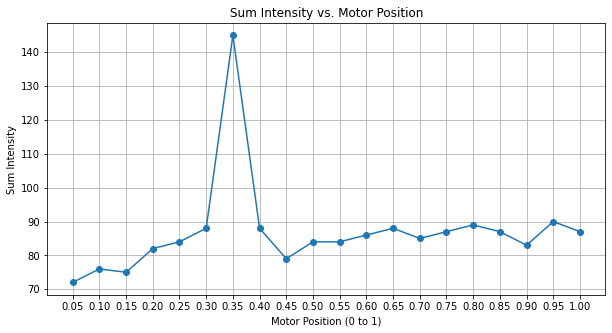

In [122]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.05 for i in range(20)]  # Each step of 0.05

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.xticks(x_values)  # Set x ticks for clarity
plt.show()

Finally see something! Repeat it: 

In [127]:
# 20 points with a step of 0.05

sum_intensities = []

for i in range(50):
    value = 0.02  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(0.5)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

Current state: 0.02
Sum intensity: 91
Current state: 0.04
Sum intensity: 85
Current state: 0.06
Sum intensity: 87
Current state: 0.08
Sum intensity: 86
Current state: 0.10
Sum intensity: 90
Current state: 0.12
Sum intensity: 81
Current state: 0.14
Sum intensity: 86
Current state: 0.16
Sum intensity: 78
Current state: 0.18
Sum intensity: 85
Current state: 0.20
Sum intensity: 87
Current state: 0.22
Sum intensity: 91
Current state: 0.24
Sum intensity: 89
Current state: 0.26
Sum intensity: 92
Current state: 0.28
Sum intensity: 83
Current state: 0.30
Sum intensity: 93
Current state: 0.32
Sum intensity: 84
Current state: 0.34
Sum intensity: 90
Current state: 0.36
Sum intensity: 85
Current state: 0.38
Sum intensity: 90
Current state: 0.40
Sum intensity: 91
Current state: 0.42
Sum intensity: 85
Current state: 0.44
Sum intensity: 85
Current state: 0.46
Sum intensity: 86
Current state: 0.48
Sum intensity: 82
Current state: 0.50
Sum intensity: 88
Current state: 0.52
Sum intensity: 92
Current stat

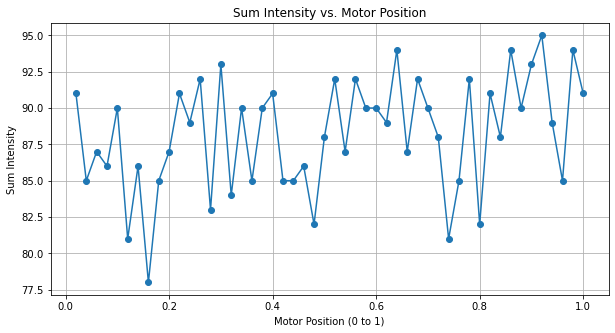

In [132]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.02 for i in range(50)]  # Each step of 0.02

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [144]:
print(move_rotary_motor(-0.2))

Current state: 0.00
open


The current beam that can hit the mirror level cannot go to the YAG, as the mirror is too high. 

In [143]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, -8)  # Move to an absolute position 

time.sleep(5)  # Wait for the motor to reach the position
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is -8.0 mm


In [147]:
# 20 points with a step of 0.05

sum_intensities = []

for i in range(50):
    value = 0.02  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(0.5)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

Current state: 0.02
Sum intensity: 74
Current state: 0.04
Sum intensity: 78
Current state: 0.06
Sum intensity: 81
Current state: 0.08
Sum intensity: 79
Current state: 0.10
Sum intensity: 77
Current state: 0.12
Sum intensity: 80
Current state: 0.14
Sum intensity: 80
Current state: 0.16
Sum intensity: 74
Current state: 0.18
Sum intensity: 77
Current state: 0.20
Sum intensity: 79
Current state: 0.22
Sum intensity: 82
Current state: 0.24
Sum intensity: 93
Current state: 0.26
Sum intensity: 91
Current state: 0.28
Sum intensity: 87
Current state: 0.30
Sum intensity: 87
Current state: 0.32
Sum intensity: 86
Current state: 0.34
Sum intensity: 83
Current state: 0.36
Sum intensity: 91
Current state: 0.38
Sum intensity: 84
Current state: 0.40
Sum intensity: 89
Current state: 0.42
Sum intensity: 87
Current state: 0.44
Sum intensity: 85
Current state: 0.46
Sum intensity: 90
Current state: 0.48
Sum intensity: 88
Current state: 0.50
Sum intensity: 87
Current state: 0.52
Sum intensity: 87
Current stat

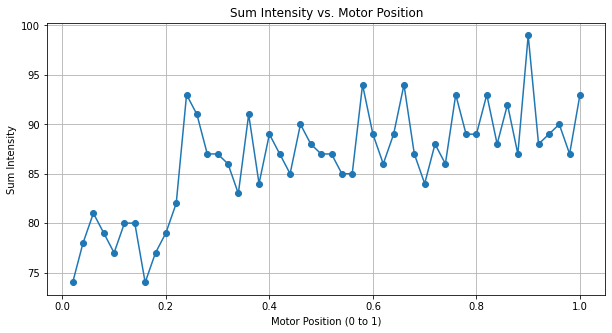

In [148]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.02 for i in range(50)]  # Each step of 0.02

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [ ]:
print(move_rotary_motor(-0.05))

Current state: 0.50
close


## Alignments


In [199]:
# 20 points with a step of 0.05

sum_intensities = []

for i in range(50):
    value = 0.02  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(0.5)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

Current state: 0.02
Sum intensity: 92
Current state: 0.04
Sum intensity: 84
Current state: 0.06
Sum intensity: 86
Current state: 0.08
Sum intensity: 83
Current state: 0.10
Sum intensity: 85
Current state: 0.12
Sum intensity: 87
Current state: 0.14
Sum intensity: 90
Current state: 0.16
Sum intensity: 91
Current state: 0.18
Sum intensity: 84
Current state: 0.20
Sum intensity: 89
Current state: 0.22
Sum intensity: 88
Current state: 0.24
Sum intensity: 84
Current state: 0.26
Sum intensity: 91
Current state: 0.28
Sum intensity: 85
Current state: 0.30
Sum intensity: 90
Current state: 0.32
Sum intensity: 89
Current state: 0.34
Sum intensity: 85
Current state: 0.36
Sum intensity: 91
Current state: 0.38
Sum intensity: 78
Current state: 0.40
Sum intensity: 74
Current state: 0.42
Sum intensity: 78
Current state: 0.44
Sum intensity: 79
Current state: 0.46
Sum intensity: 7009
Current state: 0.48
Sum intensity: 71
Current state: 0.50
Sum intensity: 78
Current state: 0.52
Sum intensity: 80
Current st

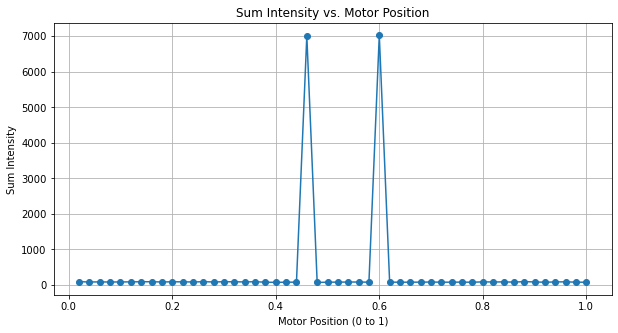

In [200]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.02 for i in range(50)]  # Each step of 0.02

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [227]:
print(x_values[22], sum_intensities[22])
print(x_values[29], sum_intensities[29])

0.46 7009
0.6 7026


CLEAR PEAK AT 0.46 adn 0.6!

In [201]:
print(move_rotary_motor(.48))

Current state: 0.48
close


Current state: 0.40
None
5271


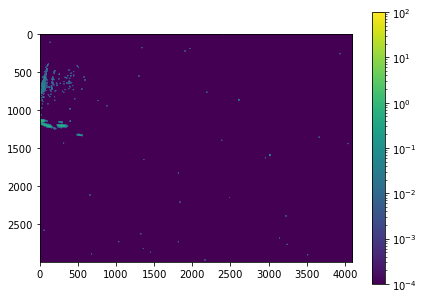

In [ ]:
print(move_rotary_motor(.2))
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Current state: 0.00
open
89


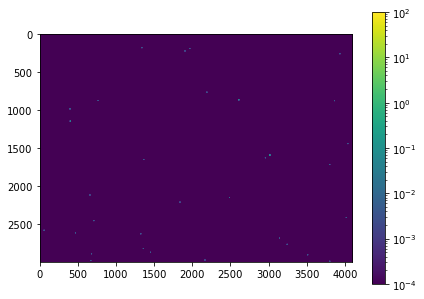

In [ ]:
print(move_rotary_motor(.36))
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Current state: 0.01
Sum intensity: 79
Current state: 0.02
Sum intensity: 78
Current state: 0.03
Sum intensity: 84
Current state: 0.04
Sum intensity: 84
Current state: 0.05
Sum intensity: 81
Current state: 0.06
Sum intensity: 89
Current state: 0.07
Sum intensity: 87
Current state: 0.08
Sum intensity: 86
Current state: 0.09
Sum intensity: 88
Current state: 0.10
Sum intensity: 85
Current state: 0.11
Sum intensity: 89
Current state: 0.12
Sum intensity: 88
Current state: 0.13
Sum intensity: 87
Current state: 0.14
Sum intensity: 86
Current state: 0.15
Sum intensity: 90
Current state: 0.16
Sum intensity: 86
Current state: 0.17
Sum intensity: 84
Current state: 0.18
Sum intensity: 90
Current state: 0.19
Sum intensity: 89
Current state: 0.20
Sum intensity: 87
Current state: 0.21
Sum intensity: 87
Current state: 0.22
Sum intensity: 85
Current state: 0.23
Sum intensity: 79
Current state: 0.24
Sum intensity: 83
Current state: 0.25
Sum intensity: 84
Current state: 0.26
Sum intensity: 74
Current stat

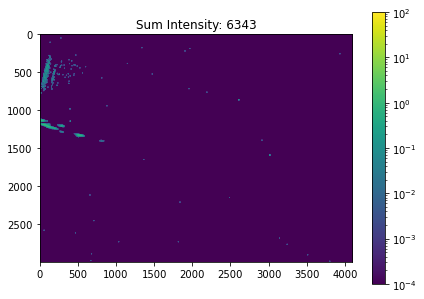

Current state: 0.47
Sum intensity: 75
Current state: 0.48
Sum intensity: 77
Current state: 0.49
Sum intensity: 77
Current state: 0.50
Sum intensity: 74
Current state: 0.51
Sum intensity: 85
Current state: 0.52
Sum intensity: 75
Current state: 0.53
Sum intensity: 84
Current state: 0.54
Sum intensity: 77
Current state: 0.55
Sum intensity: 86
Current state: 0.56
Sum intensity: 95
Current state: 0.57
Sum intensity: 81
Current state: 0.58
Sum intensity: 90
Current state: 0.59
Sum intensity: 76
Current state: 0.60
Sum intensity: 6156


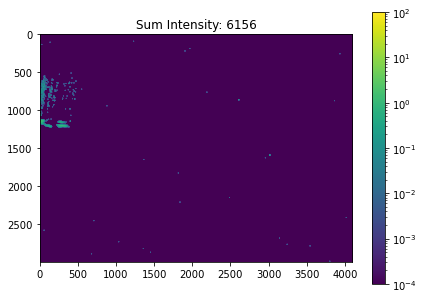

Current state: 0.61
Sum intensity: 131
Current state: 0.62
Sum intensity: 92
Current state: 0.63
Sum intensity: 86
Current state: 0.64
Sum intensity: 95
Current state: 0.65
Sum intensity: 94
Current state: 0.66
Sum intensity: 94
Current state: 0.67
Sum intensity: 84
Current state: 0.68
Sum intensity: 87
Current state: 0.69
Sum intensity: 88
Current state: 0.70
Sum intensity: 81
Current state: 0.71
Sum intensity: 90
Current state: 0.72
Sum intensity: 79
Current state: 0.73
Sum intensity: 91
Current state: 0.74
Sum intensity: 88
Current state: 0.75
Sum intensity: 83
Current state: 0.76
Sum intensity: 90
Current state: 0.77
Sum intensity: 83
Current state: 0.78
Sum intensity: 94
Current state: 0.79
Sum intensity: 92
Current state: 0.80
Sum intensity: 92
Current state: 0.81
Sum intensity: 91
Current state: 0.82
Sum intensity: 84
Current state: 0.83
Sum intensity: 94
Current state: 0.84
Sum intensity: 83
Current state: 0.85
Sum intensity: 83
Current state: 0.86
Sum intensity: 87
Current sta

In [239]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

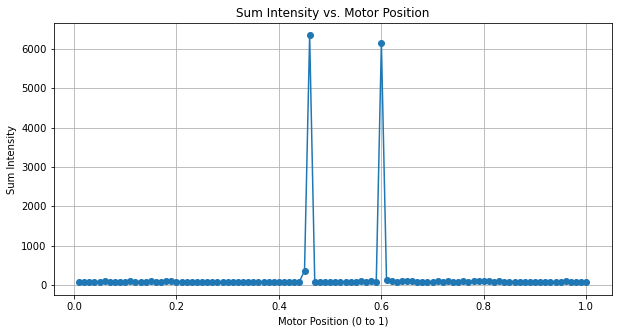

In [240]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [241]:
move_rotary_motor(0.46)

Current state: 0.46


'close'

8196


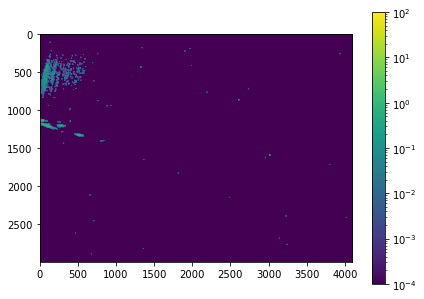

In [244]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Slightly rotate left and right of the laser. 

Current state: 0.01
Sum intensity: 67
Current state: 0.02
Sum intensity: 78
Current state: 0.03
Sum intensity: 69
Current state: 0.04
Sum intensity: 79
Current state: 0.05
Sum intensity: 74
Current state: 0.06
Sum intensity: 79
Current state: 0.07
Sum intensity: 77
Current state: 0.08
Sum intensity: 82
Current state: 0.09
Sum intensity: 73
Current state: 0.10
Sum intensity: 80
Current state: 0.11
Sum intensity: 74
Current state: 0.12
Sum intensity: 79
Current state: 0.13
Sum intensity: 77
Current state: 0.14
Sum intensity: 72
Current state: 0.15
Sum intensity: 68
Current state: 0.16
Sum intensity: 83
Current state: 0.17
Sum intensity: 67
Current state: 0.18
Sum intensity: 78
Current state: 0.19
Sum intensity: 78
Current state: 0.20
Sum intensity: 82
Current state: 0.21
Sum intensity: 78
Current state: 0.22
Sum intensity: 83
Current state: 0.23
Sum intensity: 72
Current state: 0.24
Sum intensity: 80
Current state: 0.25
Sum intensity: 79
Current state: 0.26
Sum intensity: 79
Current stat

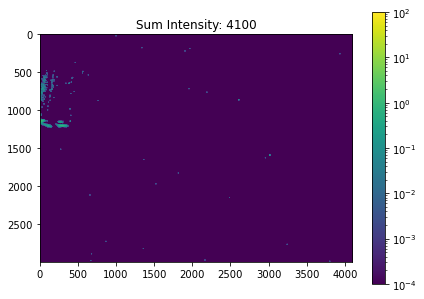

Current state: 0.47
Sum intensity: 85
Current state: 0.48
Sum intensity: 90
Current state: 0.49
Sum intensity: 80
Current state: 0.50
Sum intensity: 76
Current state: 0.51
Sum intensity: 83
Current state: 0.52
Sum intensity: 86
Current state: 0.53
Sum intensity: 80
Current state: 0.54
Sum intensity: 84
Current state: 0.55
Sum intensity: 75
Current state: 0.56
Sum intensity: 84
Current state: 0.57
Sum intensity: 81
Current state: 0.58
Sum intensity: 84
Current state: 0.59
Sum intensity: 680


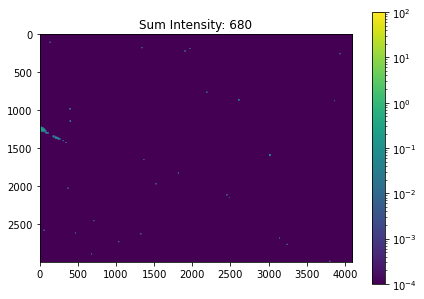

Current state: 0.60
Sum intensity: 6909


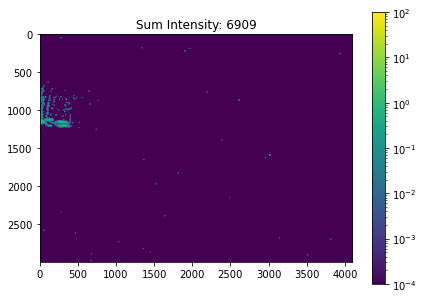

Current state: 0.61
Sum intensity: 78
Current state: 0.62
Sum intensity: 78
Current state: 0.63
Sum intensity: 68
Current state: 0.64
Sum intensity: 77
Current state: 0.65
Sum intensity: 79
Current state: 0.66
Sum intensity: 75
Current state: 0.67
Sum intensity: 76
Current state: 0.68
Sum intensity: 78
Current state: 0.69
Sum intensity: 76
Current state: 0.70
Sum intensity: 77
Current state: 0.71
Sum intensity: 80
Current state: 0.72
Sum intensity: 75
Current state: 0.73
Sum intensity: 80
Current state: 0.74
Sum intensity: 76
Current state: 0.75
Sum intensity: 75
Current state: 0.76
Sum intensity: 77
Current state: 0.77
Sum intensity: 73
Current state: 0.78
Sum intensity: 79
Current state: 0.79
Sum intensity: 79
Current state: 0.80
Sum intensity: 73
Current state: 0.81
Sum intensity: 78
Current state: 0.82
Sum intensity: 74
Current state: 0.83
Sum intensity: 71
Current state: 0.84
Sum intensity: 76
Current state: 0.85
Sum intensity: 79
Current state: 0.86
Sum intensity: 83
Current stat

In [262]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

In [265]:
print(move_rotary_motor(0.1))

Current state: 0.35
None


Current state: 0.01
Sum intensity: 73
Current state: 0.02
Sum intensity: 79
Current state: 0.03
Sum intensity: 70
Current state: 0.04
Sum intensity: 73
Current state: 0.05
Sum intensity: 76
Current state: 0.06
Sum intensity: 77
Current state: 0.07
Sum intensity: 81
Current state: 0.08
Sum intensity: 69
Current state: 0.09
Sum intensity: 80
Current state: 0.10
Sum intensity: 72
Current state: 0.11
Sum intensity: 78
Current state: 0.12
Sum intensity: 67
Current state: 0.13
Sum intensity: 66
Current state: 0.14
Sum intensity: 62
Current state: 0.15
Sum intensity: 65
Current state: 0.16
Sum intensity: 72
Current state: 0.17
Sum intensity: 68
Current state: 0.18
Sum intensity: 69
Current state: 0.19
Sum intensity: 65
Current state: 0.20
Sum intensity: 74
Current state: 0.21
Sum intensity: 76
Current state: 0.22
Sum intensity: 66
Current state: 0.23
Sum intensity: 66
Current state: 0.24
Sum intensity: 70
Current state: 0.25
Sum intensity: 73
Current state: 0.26
Sum intensity: 72
Current stat

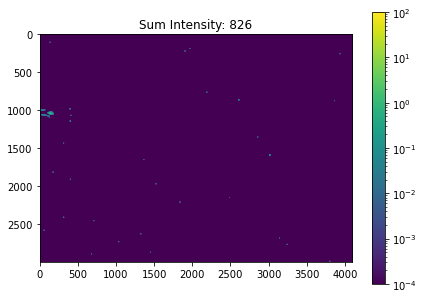

Current state: 0.47
Sum intensity: 3271


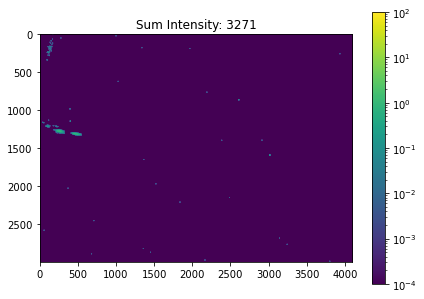

Current state: 0.48
Sum intensity: 78
Current state: 0.49
Sum intensity: 74
Current state: 0.50
Sum intensity: 76
Current state: 0.51
Sum intensity: 76
Current state: 0.52
Sum intensity: 75
Current state: 0.53
Sum intensity: 76
Current state: 0.54
Sum intensity: 75
Current state: 0.55
Sum intensity: 77
Current state: 0.56
Sum intensity: 75
Current state: 0.57
Sum intensity: 84
Current state: 0.58
Sum intensity: 76
Current state: 0.59
Sum intensity: 2399


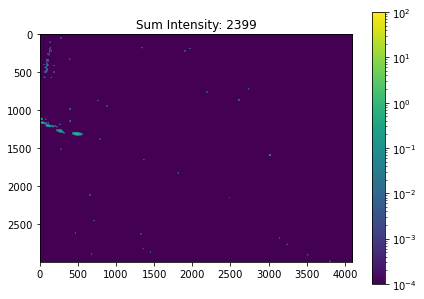

Current state: 0.60
Sum intensity: 651


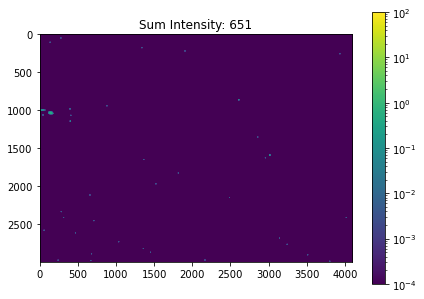

Current state: 0.61
Sum intensity: 76
Current state: 0.62
Sum intensity: 77
Current state: 0.63
Sum intensity: 74
Current state: 0.64
Sum intensity: 80
Current state: 0.65
Sum intensity: 80
Current state: 0.66
Sum intensity: 72
Current state: 0.67
Sum intensity: 76
Current state: 0.68
Sum intensity: 75
Current state: 0.69
Sum intensity: 72
Current state: 0.70
Sum intensity: 77
Current state: 0.71
Sum intensity: 80
Current state: 0.72
Sum intensity: 77
Current state: 0.73
Sum intensity: 80
Current state: 0.74
Sum intensity: 75
Current state: 0.75
Sum intensity: 72
Current state: 0.76
Sum intensity: 76
Current state: 0.77
Sum intensity: 70
Current state: 0.78
Sum intensity: 78
Current state: 0.79
Sum intensity: 74
Current state: 0.80
Sum intensity: 77
Current state: 0.81
Sum intensity: 73
Current state: 0.82
Sum intensity: 73
Current state: 0.83
Sum intensity: 77
Current state: 0.84
Sum intensity: 77
Current state: 0.85
Sum intensity: 79
Current state: 0.86
Sum intensity: 80
Current stat

In [292]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

In [69]:
print(move_rotary_motor(0.5))

Current state: 0.00
open


In [70]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

Current state: 0.01
Sum intensity: 89
Current state: 0.02
Sum intensity: 85
Current state: 0.03
Sum intensity: 83
Current state: 0.04
Sum intensity: 85
Current state: 0.05
Sum intensity: 87
Current state: 0.06
Sum intensity: 85
Current state: 0.07
Sum intensity: 87
Current state: 0.08
Sum intensity: 87
Current state: 0.09
Sum intensity: 82
Current state: 0.10
Sum intensity: 87
Current state: 0.11
Sum intensity: 85
Current state: 0.12
Sum intensity: 85
Current state: 0.13
Sum intensity: 84
Current state: 0.14
Sum intensity: 82
Current state: 0.15
Sum intensity: 85
Current state: 0.16
Sum intensity: 88
Current state: 0.17
Sum intensity: 89
Current state: 0.18
Sum intensity: 83
Current state: 0.19
Sum intensity: 95
Current state: 0.20
Sum intensity: 96
Current state: 0.21
Sum intensity: 87
Current state: 0.22
Sum intensity: 89
Current state: 0.23
Sum intensity: 79
Current state: 0.24
Sum intensity: 94
Current state: 0.25
Sum intensity: 96
Current state: 0.26
Sum intensity: 78
Current stat

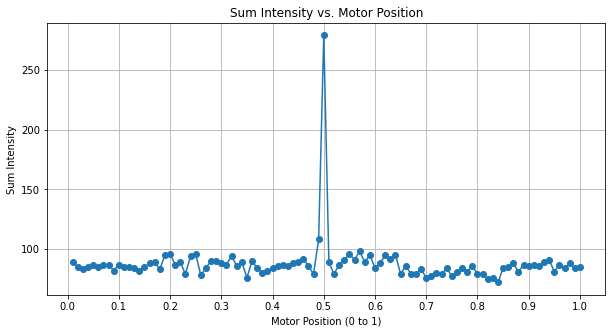

In [72]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.xticks(np.arange(0, 1.1, 0.1))  # Set x ticks for clarity
plt.grid(True)
plt.show()

In [74]:
print(move_rotary_motor(0.5))

Current state: 0.00
open


Current state: 0.01
Sum intensity: 86
Current state: 0.02
Sum intensity: 84
Current state: 0.03
Sum intensity: 84
Current state: 0.04
Sum intensity: 84
Current state: 0.05
Sum intensity: 88
Current state: 0.06
Sum intensity: 86
Current state: 0.07
Sum intensity: 82
Current state: 0.08
Sum intensity: 92
Current state: 0.09
Sum intensity: 89
Current state: 0.10
Sum intensity: 91
Current state: 0.11
Sum intensity: 85
Current state: 0.12
Sum intensity: 92
Current state: 0.13
Sum intensity: 85
Current state: 0.14
Sum intensity: 87
Current state: 0.15
Sum intensity: 85
Current state: 0.16
Sum intensity: 82
Current state: 0.17
Sum intensity: 90
Current state: 0.18
Sum intensity: 85
Current state: 0.19
Sum intensity: 85
Current state: 0.20
Sum intensity: 84
Current state: 0.21
Sum intensity: 96
Current state: 0.22
Sum intensity: 85
Current state: 0.23
Sum intensity: 86
Current state: 0.24
Sum intensity: 94
Current state: 0.25
Sum intensity: 85
Current state: 0.26
Sum intensity: 85
Current stat

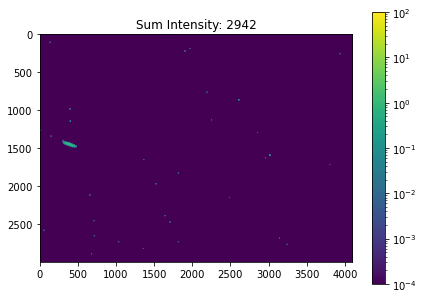

Current state: 0.50
Sum intensity: 521


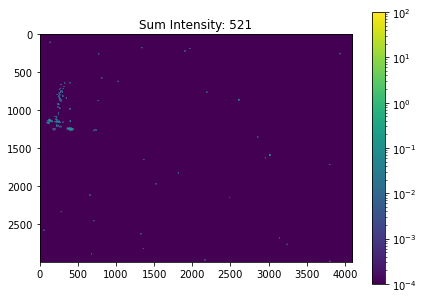

Current state: 0.51
Sum intensity: 87
Current state: 0.52
Sum intensity: 94
Current state: 0.53
Sum intensity: 80
Current state: 0.54
Sum intensity: 83
Current state: 0.55
Sum intensity: 81
Current state: 0.56
Sum intensity: 83
Current state: 0.57
Sum intensity: 83
Current state: 0.58
Sum intensity: 93
Current state: 0.59
Sum intensity: 94
Current state: 0.60
Sum intensity: 88
Current state: 0.61
Sum intensity: 77
Current state: 0.62
Sum intensity: 77
Current state: 0.63
Sum intensity: 92
Current state: 0.64
Sum intensity: 77
Current state: 0.65
Sum intensity: 78
Current state: 0.66
Sum intensity: 76
Current state: 0.67
Sum intensity: 87
Current state: 0.68
Sum intensity: 77
Current state: 0.69
Sum intensity: 87
Current state: 0.70
Sum intensity: 80
Current state: 0.71
Sum intensity: 86
Current state: 0.72
Sum intensity: 76
Current state: 0.73
Sum intensity: 72
Current state: 0.74
Sum intensity: 79
Current state: 0.75
Sum intensity: 82
Current state: 0.76
Sum intensity: 79
Current stat

In [75]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

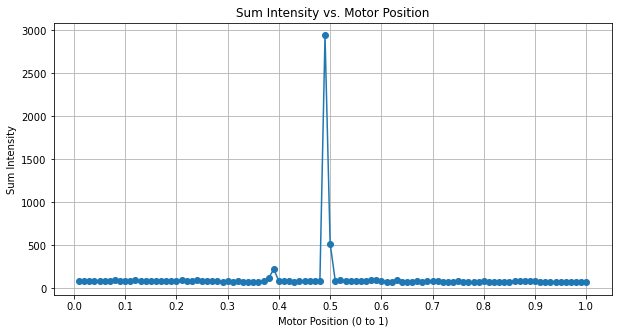

In [76]:
# Define the x-axis values (0 to 1 with 21 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.xticks(np.arange(0, 1.1, 0.1))  # Set x ticks for clarity
plt.grid(True)
plt.show()

# Archived

## camera controls

### grabbing an image

### translating the camera signal into a matrix

In [34]:
img_np = np.array(img.Array)

In [35]:
np.sum(img_np)

82

### displaying the data

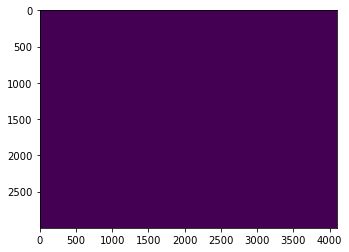

In [36]:
import matplotlib.pyplot as plt
plt.imshow(img_np)
plt.show()

## processing the data

### thresholding to remove ambiant light

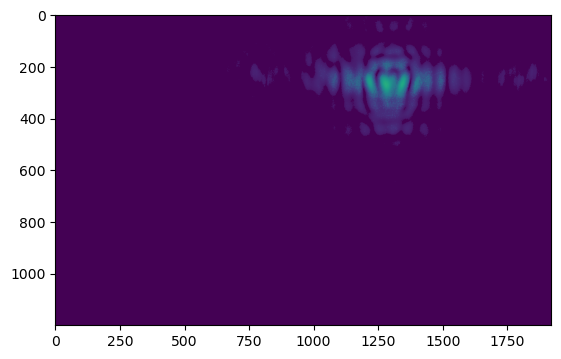

In [8]:
img_thr = img_np
img_thr[img_thr<60] = 0
plt.imshow(img_thr)
plt.show()

### extracting beam data

In [9]:
def beam_stat_px(x, y):
    I = np.abs(y **2)/np.max(np.abs(y **2))
    mu_px = np.sum(x * y)/np.sum(y)
    sigma_px= np.sqrt(np.sum((x - mu_px)**2 * y)/np.sum(y))
    return(mu_px, sigma_px)

In [10]:
Ix = np.sum(img_thr,axis=0)
Iy = np.sum(img_thr,axis=1)

In [11]:
Nx = np.shape(Ix)[0]
Ny = np.shape(Iy)[0]
x_px=np.arange(Nx)
y_px=np.arange(Ny)

(mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
(muy_px, sigmay_px) = beam_stat_px(y_px, Iy)

print('horizontal centroid is at %1.2f px' % mux_px)
print('vertical centroid is at %1.2f px' % muy_px)


horizontal centroid is at 1289.53 px
vertical centroid is at 262.69 px


### static data acquisition over ~3h

DO NOT RUN ! VERY LONG

In [124]:
import time
Nt = 10000 # about 10000 since settle time is 1sec
xx = np.zeros(Nt)
yy = np.zeros(Nt)
for i_t in np.arange(Nt):
    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<50] = 0
    Ix = np.sum(img_thr,axis=0)
    Iy = np.sum(img_thr,axis=1)
    Nx = np.shape(Ix)[0]
    Ny = np.shape(Iy)[0]
    x_px=np.arange(Nx)
    y_px=np.arange(Ny)
    (mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
    (muy_px, sigmay_px) = beam_stat_px(y_px, Iy)
    xx[i_t]= mux_px
    yy[i_t]= muy_px
    #print(i_t)

    filename = 'xx.npz'

    f = open('xx.npz', 'wb')
    np.save(f, xx)
    f.close()

    f = open('yy.npz', 'wb')
    np.save(f, yy)
    f.close()

### display data

In [12]:
plt.plot(xx)

plt.xlabel('time [sec]')
plt.ylabel('horizontal centroid [px]')
plt.show()

NameError: name 'xx' is not defined

In [13]:
plt.plot(yy)

plt.xlabel('time [sec]')
plt.ylabel('vertical centroid [px]')
plt.show()

NameError: name 'yy' is not defined

In [21]:
# ok for debugging, but avoid
#bcs.MoveMotor(bcs_id_rotary, 1)

### useful function for moving the stage
Adding soft limits for the linear stage, to avoid crash
## IMPORTANT

In [22]:
def GetPos(name):
    pos_str = bcs.GetMotorPos(name)
    pos_ct = int(float(pos_str.rstrip()))
    return pos_ct
GetPos(bcs_id_linear)

def GetStatus(name):
    stat = bcs.GetMotorStat(name)
    #if self.verbose:
    #    print(name+" Status = " + stat)
    return ((stat[5] == "f") or (stat[5] == "F"))   # should this be 'F'??? Oh well, check for both
GetStatus(bcs_id_linear)
print('linear stage status: %i' %GetStatus(bcs_id_linear))

#hard coded limits
def GetLimits(name):
    if (name == bcs_id_linear):
        ####### HERE ###########
        lim = (-40, -3) #change me as needed
        ########################
    if (name == bcs_id_rotary):
        lim = (-10, 10)
    return lim
GetLimits(bcs_id_linear)


linear stage status: 1


(-40, -3)

In [23]:
def Move(name, pos_ct):
    #print("Starting a move from %i " % pos + " to %i" % pos_ct + " time %10.3f " % (time.time() % 100))
    lim = GetLimits(name)  # Sofware limits. this is a tuple (limit0, limit1)
    p1 = np.max((lim[0], pos_ct))
    p = np.min((p1, lim[1]))  # bound it to the limits
    
    if (pos_ct > lim[1]): print("Move: "+name+" was constrained to the upper limit")
    if (pos_ct < lim[0]): print("Move: "+name+" was constrained to the lower limit")
    
        # the time-out clock starts when we see that it is no longer moving.
    time_allowed = 5.0           # Fail after 7 seconds of no motion.
    t_check_delay = 0.1          # Don't check more often than than
    moving_tolerance = 10        # If position difference is below this, then we're not moving much.
    t_last = time.time()         # Used for the total time.
    t_timeout_start = t_last
    pos_last = GetPos(name)
    bcs.MoveMotor(name, p)  # Launch the move ********** Now we watch

    #some issue with linear motor status (returns False even after a move)

    # move_is_not_done = True
    # while move_is_not_done:
    #     tnow = time.time()
    #     if ((tnow - t_last) > t_check_delay):  # It's been long enough, we can check
    #         status = GetStatus(name)        # Check: are we done?
    #         if status:
    #             move_is_not_done = False  # this will end the loop. Great!
    #         else:
    #             pos_now = GetPos(name)
    #             tnow = time.time()
    #             if (pos_now - pos_last) >= moving_tolerance:  # we still moving, not done
    #                 t_timeout_start = tnow  # advance this clock to represent the last time we know it was moving
    #                 pos_last = pos_now      # advance the last known position
    #             else:                                         # We must be slowing down to stop
    #                 if (tnow - t_timeout_start) > time_allowed:
    #                     print("    " + name + " Move timed out...")
    #                     move_is_not_done = False  # this will end the loop. Sad.   

In [24]:
# testing the linear stage
# Move(bcs_id_linear, -10)

### wrapping the centroid analysis a little better

In [25]:
def GetCentroid(img_thr):
    Ix = np.sum(img_thr,axis=0)
    Iy = np.sum(img_thr,axis=1)
    Nx = np.shape(Ix)[0]
    Ny = np.shape(Iy)[0]
    x_px=np.arange(Nx)
    y_px=np.arange(Ny)
    (mux_px, sigmax_px) = beam_stat_px(x_px, Ix)
    (muy_px, sigmay_px) = beam_stat_px(y_px, Iy)
    return (mux_px, muy_px)

### make sure there is signal on the camera

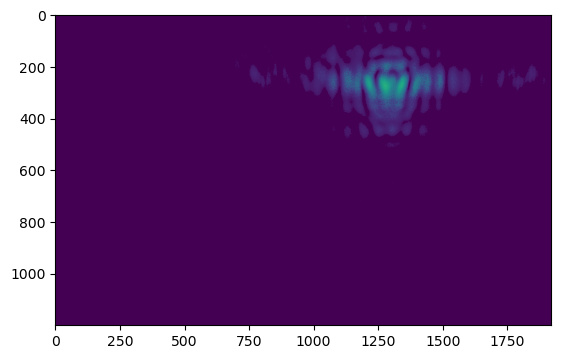

In [26]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())


img_np = np.array(camera.GrabOne(timeoutMs).Array)
img_thr = img_np
img_thr[img_thr<60] = 0
(mux_px, muy_px) = GetCentroid(img_thr)
plt.imshow(img_thr)
plt.show()

camera.Close()

## Scan the linear stage

In [27]:
# open the camer

camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

import time

# number of point to scan 
Nt = 200

# range of motion
lin_pos_array_mm = np.linspace(-33,-7,Nt)
xx_lin_px = np.zeros(Nt)
yy_lin_px = np.zeros(Nt)

# move to first position
Move(bcs_id_linear, lin_pos_array_mm[0])
#settle time
time.sleep(10)

# start scanning
for i_t in np.arange(Nt):
    Move(bcs_id_linear, lin_pos_array_mm[i_t])
    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_lin_px[i_t]= mux_px
    yy_lin_px[i_t]= muy_px

    filename1 = 'xx_lin_px.npz'
    filename2 = 'yy_lin_px.npz'
    filename3 = 'lin_pos_array_mm.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_lin_px)
    np.save(f2, yy_lin_px)
    np.save(f3, lin_pos_array_mm)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

### display data

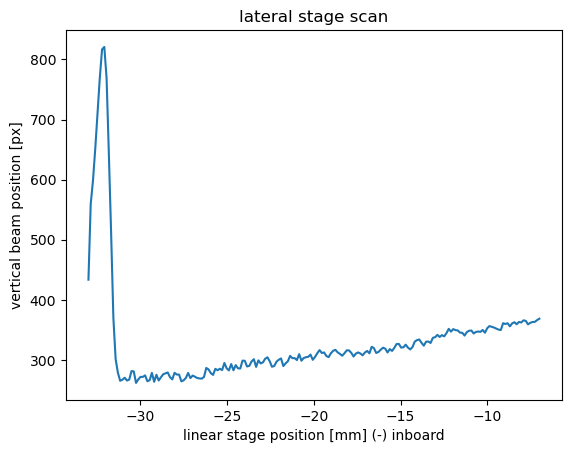

In [28]:
plt.plot(lin_pos_array_mm,yy_lin_px)
plt.xlabel('linear stage position [mm] (-) inboard')
plt.ylabel('vertical beam position [px]')
plt.title('lateral stage scan')
plt.show()

## rotary stage scan

In [29]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

# apex position
apex_rev = -0.7973  
# number of points to scan around the apex
Nt = 40
# step size
step_rev = 0.1*1/360 # 0.1deg

rot_pos_array_rev = np.zeros(Nt)
xx_rot_px = np.zeros(Nt)
yy_rot_px = np.zeros(Nt)

import time
# move to initial position
for i_t in range(Nt):
    rot_pos_array_rev[i_t] = apex_rev + (i_t-Nt/2)*step_rev
    Move(bcs_id_rotary, rot_pos_array_rev[i_t])

    time.sleep(1)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_rot_px[i_t]= mux_px
    yy_rot_px[i_t]= muy_px
    #print(i_t)

    filename1 = 'xx_rot_px.npz'
    filename2 = 'yy_rot_px.npz'
    filename3 = 'rot_pos_array_rev.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_rot_px)
    np.save(f2, yy_rot_px)
    np.save(f3, rot_pos_array_rev)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

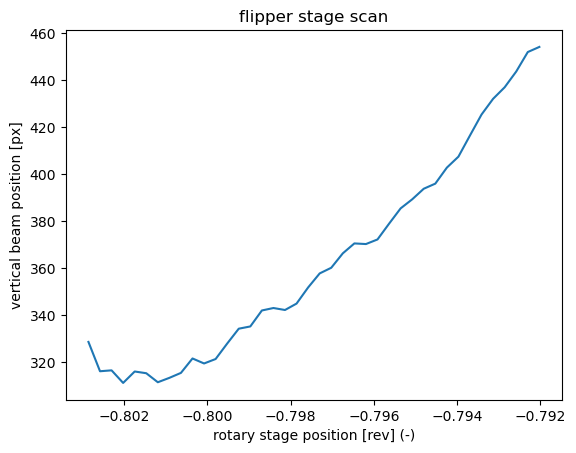

In [31]:
plt.plot(rot_pos_array_rev,yy_rot_px)
plt.xlabel('rotary stage position [rev] (-)')
plt.ylabel('vertical beam position [px]')
plt.title('flipper stage scan')
plt.show()

In [32]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())

# apex position
apex_rev = 0.5095
# number of points to scan around the apex
Nt = 20
# step size
step_rev = 0.03

rot_posrep_array_rev = np.zeros(Nt)
xx_rotrep_px = np.zeros(Nt)
yy_rotrep_px = np.zeros(Nt)

import time
# move to initial position
for i_t in range(Nt):
    rot_posrep_array_rev[i_t] = apex_rev + step_rev*np.mod(i_t,2)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)
    Move(bcs_id_rotary, rot_posrep_array_rev[i_t])
    time.sleep(0.1)

    time.sleep(3)
    img_np = np.array(camera.GrabOne(timeoutMs).Array)
    img_thr = img_np
    img_thr[img_thr<60] = 0
    (mux_px, muy_px) = GetCentroid(img_thr)
    xx_rotrep_px[i_t]= mux_px
    yy_rotrep_px[i_t]= muy_px
    #print(i_t)



    filename1 = 'xx_rot_px.npz'
    filename2 = 'yy_rot_px.npz'
    filename3 = 'rot_pos_array_rev.npz'

    f1 = open(filename1, 'wb')
    f2 = open(filename2, 'wb')
    f3 = open(filename3, 'wb')
    np.save(f1, xx_rotrep_px)
    np.save(f2, yy_rotrep_px)
    np.save(f3, rot_posrep_array_rev)
    f1.close()
    f2.close()
    f3.close()

camera.Close()

C:\Users\lbnl-guest\AppData\Local\Temp\ipykernel_2008\1232522220.py:2: RuntimeWarning: invalid value encountered in divide
  I = np.abs(y **2)/np.max(np.abs(y **2))
C:\Users\lbnl-guest\AppData\Local\Temp\ipykernel_2008\1232522220.py:3: RuntimeWarning: invalid value encountered in scalar divide
  mu_px = np.sum(x * y)/np.sum(y)


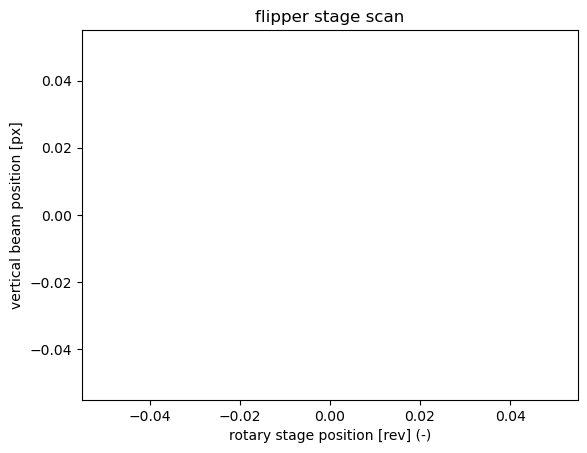

In [34]:
plt.plot(yy_rotrep_px)
plt.xlabel('rotary stage position [rev] (-)')
plt.ylabel('vertical beam position [px]')
plt.title('flipper stage scan')
plt.show()